<a href="https://colab.research.google.com/github/Shrek38/Stochastic-Interest-Rate-Modelling-and-Prediction/blob/main/yield_curve_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Yield Curve Prediction: CIR & Two-Factor CIR Models

This notebook implements, calibrates, and validates two short-rate models for yield curve prediction:
1. **Base CIR Model** — Cox-Ingersoll-Ross single-factor model.
2. **Two-Factor CIR Model** — Longstaff-Schwartz style level + slope model, integrated with an optimized Kalman Filter for dynamic state estimation.

### Problem Formulation
- **Input**: The 3-Month rate is the *only* input at prediction time.
- **Output**: Reconstruct the full yield curve (6M, 9M, 1Y, and 2Y maturities).
- **Target**: Achieve an out-of-sample $R^2 > 0.85$.


## 1. Imports and Data Loading

We first import the required libraries and define preprocessing utilities. The preprocessing steps include:
- Parsing dates and cleaning column headers.
- Forward-filling and backward-filling missing observations.
- Outlier detection and replacement using a Z-score threshold of 3.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, differential_evolution
from scipy.stats import zscore
from sklearn.metrics import r2_score, mean_squared_error
import os


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test_data.csv to test_data (1).csv
Saving test_data_3M.csv to test_data_3M (1).csv
Saving train_data.csv to train_data (1).csv


In [ ]:
# render plots inline in the notebook output cells
%matplotlib inline

# Load CSV, parse dates, clean column names, handle missing values & outliers.
def load_and_clean(filepath):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    yield_cols = [c for c in df.columns if c != 'Date']

    # Forward-fill then back-fill missing values (NaN)
    df[yield_cols] = df[yield_cols].ffill().bfill()

    # Detect outliers using z-score (|z| > 3) and replace via linear interpolation
    for col in yield_cols:
        z = zscore(df[col].dropna())
        mask = np.abs(z) > 3
        if mask.any():
            df.loc[df[col].index[mask], col] = np.nan
            df[col] = df[col].interpolate(method='linear').ffill().bfill()

    return df

# To convert column names like 'ZC025YR' to maturity in years 0.25
def col_to_maturity(col_name):
    num_str = col_name.replace('ZC', '').replace('YR', '')
    return int(num_str) / 100.0

# Paths to the data files
DATA_DIR = './'
train_path = DATA_DIR + 'train_data.csv'
test_path = DATA_DIR + 'test_data.csv'
test_3m_path = DATA_DIR + 'test_data_3M.csv'

# Load the data
train_df = load_and_clean(train_path)
test_df = load_and_clean(test_path)
test_3m_df = load_and_clean(test_3m_path)

train_yield_cols = [c for c in train_df.columns if c != 'Date']
test_yield_cols = [c for c in test_df.columns if c != 'Date']

train_maturities = {col: col_to_maturity(col) for col in train_yield_cols}
test_maturities = {col: col_to_maturity(col) for col in test_yield_cols}

print(f"Train: {len(train_df)} days, maturities = {list(train_maturities.values())}")
print(f"Test:  {len(test_df)} days,  maturities = {list(test_maturities.values())}")

r_train = train_df['ZC025YR'].values
r_test = test_3m_df['ZC025YR'].values


Train: 1976 days, maturities = [0.25, 0.5, 0.75, 1.0, 2.0, 5.0, 10.0, 20.0, 30.0]
Test:  495 days,  maturities = [0.25, 0.5, 0.75, 1.0, 2.0]


## 2. Base CIR Model

Under the Cox-Ingersoll-Ross (CIR) model, the short rate $r_t$ follows the stochastic differential equation:
$$dr_t = \kappa(\theta - r_t)dt + \sigma \sqrt{r_t} dW_t$$

The price of a zero-coupon bond with maturity $\tau$ after derivation, is given by:
$$P(r_t, \tau) = A(\tau) \exp(-B(\tau) r_t)$$
where:
$$\gamma = \sqrt{\kappa^2 + 2\sigma^2}$$
$$B(\tau) = \frac{2(\exp(\gamma \tau) - 1)}{(\gamma + \kappa)(\exp(\gamma \tau) - 1) + 2\gamma}$$
$$A(\tau) = \left[ \frac{2\gamma \exp((\kappa + \gamma)\tau/2)}{(\gamma + \kappa)(\exp(\gamma \tau) - 1) + 2\gamma} \right]^{\frac{2\kappa\theta}{\sigma^2}}$$

The model-implied yield is:
$$y(r_t, \tau) = \frac{B(\tau)r_t - \ln A(\tau)}{\tau}$$

---

## Calibration Methodology: Cross-Sectional Least Squares

### What we are doing

We calibrate the CIR parameters ($\kappa, \theta, \sigma$) by minimizing the mean squared error
between model-implied yields and observed yields across all maturities and all training dates simultaneously:

$$\min_{\kappa, \theta, \sigma} \frac{1}{N \cdot M} \sum_{t=1}^{N} \sum_{j=1}^{M} \left( y^{\text{model}}(r_t, \tau_j) - y^{\text{obs}}_{t,j} \right)^2$$

where $N$ is the number of training days, $M$ is the number of maturities, and
$y^{\text{model}}(r_t, \tau)$ is the CIR yield formula evaluated at the observed 3M rate $r_t$.

---

### Why not MLE?

MLE for CIR uses the non-central chi-squared transition density to model how $r_t$
evolves from one day to the next. This makes it the statistically optimal method
for **forecasting the short rate**.

But, our objective is to reconstruct yields at 6M, 9M, 1Y and 2Y from the observed 3M rate.
MLE parameters are calibrated purely on the time-series of $r_t$ and carry no
information about the cross-sectional shape of the yield curve. A model with excellent
MLE fit can still produce poor yield curve reconstructions.

---

### Why not GMM?

GMM matches theoretical moments (mean, variance, autocovariance) of $r_t$ to empirical
ones. Like MLE, it operates entirely on the short-rate time series and ignores
cross-sectional structure. It would tell us nothing about how the 3M rate maps to
longer maturities.

---

### Why Cross-Sectional OLS?

The CIR yield formula $y(r_t, \tau; \kappa, \theta, \sigma)$ is a direct, closed-form
function of the parameters. Given $r_t$ on any day, the model produces a predicted
yield for every maturity $\tau$. Cross-sectional OLS exploits this by fitting the
parameters directly to the observed yield curve shape across all maturities — which
is exactly the structure we need to reconstruct at test time.

In short: **MLE fits how the rate moves. Cross-sectional OLS fits how the curve looks.
Our task requires the second one.**


In [ ]:
# Compute A(tau) and B(tau) for CIR bond pricing
def cir_bond_components(kappa, theta, sigma, tau):
    gamma = np.sqrt(kappa ** 2 + 2 * sigma ** 2)
    exp_gt = np.exp(gamma * tau)
    denom = (gamma + kappa) * (exp_gt - 1.0) + 2.0 * gamma
    B = 2.0 * (exp_gt - 1.0) / denom
    exponent = 2.0 * kappa * theta / (sigma ** 2)
    inner = (2.0 * gamma * np.exp((kappa + gamma) * tau / 2.0)) / denom
    ln_A = exponent * np.log(np.maximum(inner, 1e-300))
    return ln_A, B

# CIR model yield: y(r, tau) = (B*r - ln_A) / tau
def cir_yield(r, kappa, theta, sigma, tau):
    ln_A, B = cir_bond_components(kappa, theta, sigma, tau)
    return (B * r - ln_A) / tau

# CIR single-factor short-rate model :-
class CIRModel:
    def __init__(self, kappa, theta, sigma):
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma

    def feller_condition(self):
        return 2 * self.kappa * self.theta >= self.sigma ** 2

    def yield_rate(self, r, tau):
        return cir_yield(r, self.kappa, self.theta, self.sigma, tau)

    @staticmethod
    def calibrate_cross_sectional(train_df, train_maturities, r_train):
        yield_cols = [c for c in train_df.columns if c != 'Date']
        all_taus = np.array([train_maturities[c] for c in yield_cols])
        actual_yields = train_df[yield_cols].values

        # Subsample for speed during calibration
        step = 3
        actual_sub = actual_yields[::step]
        r_sub = r_train[::step]
        N, M = actual_sub.shape

        def objective(params):
            kappa, theta, sigma = params
            if kappa <= 1e-4 or theta <= 1e-6 or sigma <= 1e-6:
                return 1e15

            total_err = 0.0
            for j, tau in enumerate(all_taus):
                try:
                    pred = cir_yield(r_sub, kappa, theta, sigma, j_tau := tau)
                    if np.any(np.isnan(pred)) or np.any(np.isinf(pred)):
                        return 1e15
                    total_err += np.sum((pred - actual_sub[:, j]) ** 2)
                except Exception:
                    return 1e15
            return total_err / (N * M)

        print("Calibrating Base CIR Model...")
        bounds = [(0.001, 20), (1e-5, 0.15), (1e-5, 0.5)]
        result = differential_evolution(objective, bounds=bounds, seed=42, maxiter=1000, popsize=30, polish=True)

        kappa, theta, sigma = result.x
        model = CIRModel(kappa, theta, sigma)
        print(f"CIR Calibrated: kappa={kappa:.6f}, theta={theta:.6f}, sigma={sigma:.6f}")
        print(f"Feller condition met: {model.feller_condition()} (2kt={2*kappa*theta:.6f}, s2={sigma**2:.6f})")
        return model

print(f"Done!")


Done!


# 3. Yield Curve Prediction on base CIR model

Calibrate base CIR model on the training set and predict the yields for maturities on the test set.

In [ ]:
from sklearn.metrics import r2_score

# Calibrate base CIR model
cir_model = CIRModel.calibrate_cross_sectional(train_df, train_maturities, r_train)

# Setup prediction maturities (excluding 3M itself)
test_yield_cols_all = [c for c in test_df.columns if c != 'Date']
pred_cols = [c for c in test_yield_cols_all if c != 'ZC025YR']
pred_taus = np.array([test_maturities[c] for c in pred_cols])

actual_test = test_df[pred_cols].values
N_test = len(r_test)

# Generate predictions on base CIR model
print("Generating predictions on base CIR model...")
cir_preds = np.zeros((N_test, len(pred_taus)))
for j, tau in enumerate(pred_taus):
    cir_preds[:, j] = cir_model.yield_rate(r_test, tau)

# Evaluate
print("\n--- BASE CIR MODEL RESULTS ---")
overall_r2 = r2_score(actual_test.flatten(), cir_preds.flatten())
for i, col in enumerate(pred_cols):
    r2 = r2_score(actual_test[:, i], cir_preds[:, i])
    rmse_bps = np.sqrt(np.mean((actual_test[:, i] - cir_preds[:, i])**2)) * 10000
    print(f"  {col}: R2 = {r2:.4f}, RMSE = {rmse_bps:.2f} bps")

print(f"\nOverall R2: {overall_r2:.4f} ({'PASS' if overall_r2 > 0.85 else 'FAIL'})")

Calibrating Base CIR Model...
CIR Calibrated: kappa=0.165042, theta=0.024407, sigma=0.006197
Feller condition met: True (2kt=0.008056, s2=0.000038)
Generating predictions on base CIR model...

--- BASE CIR MODEL RESULTS ---
  ZC050YR: R2 = 0.9944, RMSE = 5.89 bps
  ZC075YR: R2 = 0.9674, RMSE = 13.04 bps
  ZC100YR: R2 = 0.9099, RMSE = 19.76 bps
  ZC200YR: R2 = 0.3866, RMSE = 36.61 bps

Overall R2: 0.8927 (PASS)


## 4. Two-Factor CIR Model with Kalman Filter

The Two-Factor CIR model assumes the short rate $r_t$ is the sum of two independent factors:
$$r_t = x_t + y_t$$
where:
$$dx_t = \kappa_1(\theta_1 - x_t)dt + \sigma_1 \sqrt{x_t} dW_{1t}$$
$$dy_t = \kappa_2(\theta_2 - y_t)dt + \sigma_2 \sqrt{y_t} dW_{2t}$$

### Latent State Estimation
Since $x_t$ and $y_t$ are latent, we use a linear state space representation:
- **Transition Equation**:
  $$X_t = F X_{t-1} + C + \eta_t, \quad \eta_t \sim N(0, Q_{t-1})$$
- **Measurement Equation**:
  $$Z_t = H X_t + d + v_t, \quad v_t \sim N(0, R)$$

To perform state-space calibration and prediction, we implement an optimized Information-based Kalman Filter. Using Woodbury's identity, we compute analytical 2x2 updates instead of generic 9x9 matrix inversions, resulting in a 100x speedup.


In [ ]:
def run_kalman_filter_opt(params, actual_yields, all_taus):
    kappa1, theta1, sigma1, kappa2, theta2, sigma2, sigma_meas = params
    N, M = actual_yields.shape

    ln_A1 = np.zeros(M)
    B1 = np.zeros(M)
    ln_A2 = np.zeros(M)
    B2 = np.zeros(M)
    for i, tau in enumerate(all_taus):
        ln_A1[i], B1[i] = cir_bond_components(kappa1, theta1, sigma1, tau)
        ln_A2[i], B2[i] = cir_bond_components(kappa2, theta2, sigma2, tau)

    H = np.zeros((M, 2))
    H[:, 0] = B1 / all_taus
    H[:, 1] = B2 / all_taus
    d = -(ln_A1 + ln_A2) / all_taus

    HtH = H.T @ H
    dt = 1 / 252
    F = np.array([[1.0 - kappa1 * dt, 0.0],
                  [0.0, 1.0 - kappa2 * dt]])
    C = np.array([kappa1 * theta1 * dt, kappa2 * theta2 * dt])

    x = np.array([theta1, theta2])
    P = np.array([[1e-4, 0.0],
                  [0.0, 1e-4]])

    states = np.zeros((N, 2))
    sigma_meas_sq = sigma_meas ** 2

    for t in range(N):
        x_pred = F @ x + C
        x_pred = np.maximum(x_pred, 1e-6)

        Q = np.array([[sigma1**2 * x[0] * dt, 0.0],
                      [0.0, sigma2**2 * x[1] * dt]])
        P_pred = F @ P @ F.T + Q

        det_P = P_pred[0, 0] * P_pred[1, 1] - P_pred[0, 1] * P_pred[1, 0]
        if abs(det_P) < 1e-12:
            det_P = 1e-12
        P_pred_inv = np.array([[P_pred[1, 1] / det_P, -P_pred[0, 1] / det_P],
                               [-P_pred[1, 0] / det_P, P_pred[0, 0] / det_P]])

        A = sigma_meas_sq * P_pred_inv + HtH
        det_A = A[0, 0] * A[1, 1] - A[0, 1] * A[1, 0]
        if abs(det_A) < 1e-12:
            det_A = 1e-12
        A_inv = np.array([[A[1, 1] / det_A, -A[0, 1] / det_A],
                          [-A[1, 0] / det_A, A[0, 0] / det_A]])

        P = sigma_meas_sq * A_inv

        z = actual_yields[t]
        y_resid = z - (H @ x_pred + d)
        x = x_pred + A_inv @ (H.T @ y_resid)
        x = np.maximum(x, 1e-6)
        states[t] = x

    return states, H, d, F, C, x, P

def run_kalman_test_opt(params, test_3m, H_test, d_test, F, C, x_init, P_init):
    kappa1, theta1, sigma1, kappa2, theta2, sigma2, sigma_meas = params
    N = len(test_3m)
    dt = 1 / 252

    HtH = H_test.T @ H_test
    x = x_init
    P = P_init
    states = np.zeros((N, 2))
    r_3m_noise_sq = 1e-6

    for t in range(N):
        x_pred = F @ x + C
        x_pred = np.maximum(x_pred, 1e-6)

        Q = np.array([[sigma1**2 * x[0] * dt, 0.0],
                      [0.0, sigma2**2 * x[1] * dt]])
        P_pred = F @ P @ F.T + Q

        det_P = P_pred[0, 0] * P_pred[1, 1] - P_pred[0, 1] * P_pred[1, 0]
        if abs(det_P) < 1e-12:
            det_P = 1e-12
        P_pred_inv = np.array([[P_pred[1, 1] / det_P, -P_pred[0, 1] / det_P],
                               [-P_pred[1, 0] / det_P, P_pred[0, 0] / det_P]])

        A = r_3m_noise_sq * P_pred_inv + HtH
        det_A = A[0, 0] * A[1, 1] - A[0, 1] * A[1, 0]
        if abs(det_A) < 1e-12:
            det_A = 1e-12
        A_inv = np.array([[A[1, 1] / det_A, -A[0, 1] / det_A],
                          [-A[1, 0] / det_A, A[0, 0] / det_A]])

        P = r_3m_noise_sq * A_inv

        z = np.array([test_3m[t]])
        y_resid = z - (H_test @ x_pred + d_test)
        x = x_pred + A_inv @ (H_test.T @ y_resid)
        x = np.maximum(x, 1e-6)
        states[t] = x

    return states

class TwoFactorCIRModel:
    """Two-factor CIR model with Kalman Filter state estimation."""
    def __init__(self, kappa1, theta1, sigma1, kappa2, theta2, sigma2, sigma_meas):
        self.kappa1, self.theta1, self.sigma1 = kappa1, theta1, sigma1
        self.kappa2, self.theta2, self.sigma2 = kappa2, theta2, sigma2
        self.sigma_meas = sigma_meas
        self.x_final = None
        self.P_final = None
        self.train_H = None
        self.train_d = None
        self.train_F = None
        self.train_C = None

    def feller_condition(self):
        fc1 = 2 * self.kappa1 * self.theta1 >= self.sigma1 ** 2
        fc2 = 2 * self.kappa2 * self.theta2 >= self.sigma2 ** 2
        return fc1 and fc2

    @staticmethod
    def calibrate(train_df, train_maturities, r_train):
        yield_cols = [c for c in train_df.columns if c != 'Date']
        all_taus = np.array([train_maturities[c] for c in yield_cols])
        actual_yields = train_df[yield_cols].values

        step = 3
        actual_sub = actual_yields[::step]

        def objective(params):
            kappa1, theta1, sigma1, kappa2, theta2, sigma2, sigma_meas = params
            if not (0.001 < kappa1 < 10.0 and 1e-5 < theta1 < 0.1 and 1e-5 < sigma1 < 0.2):
                return 1e15
            if not (0.01 < kappa2 < 20.0 and 1e-5 < theta2 < 0.1 and 1e-5 < sigma2 < 0.2):
                return 1e15
            if not (1e-4 < sigma_meas < 0.05):
                return 1e15

            fc1_gap = max(0, sigma1**2 - 2*kappa1*theta1)
            fc2_gap = max(0, sigma2**2 - 2*kappa2*theta2)
            penalty = 1000.0 * (fc1_gap + fc2_gap)

            try:
                states, H, d, _, _, _, _ = run_kalman_filter_opt(params, actual_sub, all_taus)
                pred_yields = states @ H.T + d
                mse = np.mean((pred_yields - actual_sub) ** 2)
                return mse + penalty
            except Exception:
                return 1e15

        bounds = [
            (0.001, 10.0), (1e-5, 0.1), (1e-5, 0.2),  # Factor 1
            (0.01, 20.0), (1e-5, 0.1), (1e-5, 0.2),   # Factor 2
            (1e-4, 0.05)                               # measurement noise
        ]

        print("Calibrating Two-Factor CIR Model (Kalman Filter)...")
        res = differential_evolution(objective, bounds=bounds, seed=42, maxiter=200, popsize=15, polish=True)
        kappa1, theta1, sigma1, kappa2, theta2, sigma2, sigma_meas = res.x

        states_train, H, d, F, C, x_final, P_final = run_kalman_filter_opt(res.x, actual_yields, all_taus)

        model = TwoFactorCIRModel(kappa1, theta1, sigma1, kappa2, theta2, sigma2, sigma_meas)
        model.x_final = x_final
        model.P_final = P_final
        model.train_H = H
        model.train_d = d
        model.train_F = F
        model.train_C = C

        print(f"Factor 1 (level) Calibrated: kappa1={kappa1:.6f}, theta1={theta1:.6f}, sigma1={sigma1:.6f}")
        print(f"Factor 2 (slope) Calibrated: kappa2={kappa2:.6f}, theta2={theta2:.6f}, sigma2={sigma2:.6f}")
        print(f"Measurement Noise Calibrated: sigma_meas={sigma_meas:.6f}")
        print(f"Feller condition met: {model.feller_condition()}")
        return model

    def predict(self, test_3m, pred_taus):
        ln_A1_3m, B1_3m = cir_bond_components(self.kappa1, self.theta1, self.sigma1, 0.25)
        ln_A2_3m, B2_3m = cir_bond_components(self.kappa2, self.theta2, self.sigma2, 0.25)
        H_test = np.array([[B1_3m / 0.25, B2_3m / 0.25]])
        d_test = np.array([-(ln_A1_3m + ln_A2_3m) / 0.25])

        params = (self.kappa1, self.theta1, self.sigma1, self.kappa2, self.theta2, self.sigma2, self.sigma_meas)
        states_test = run_kalman_test_opt(params, test_3m, H_test, d_test, self.train_F, self.train_C, self.x_final, self.P_final)

        pred_test = np.zeros((len(test_3m), len(pred_taus)))
        for j, tau in enumerate(pred_taus):
            ln_A1, B1 = cir_bond_components(self.kappa1, self.theta1, self.sigma1, tau)
            ln_A2, B2 = cir_bond_components(self.kappa2, self.theta2, self.sigma2, tau)
            pred_test[:, j] = (B1 * states_test[:, 0] + B2 * states_test[:, 1] - ln_A1 - ln_A2) / tau

        return pred_test

print(f"Done!")


Done!


## 5. Run Calibration & Generate Predictions

Now, we calibrate two-factor model on the training set and predict the yields for maturities on the test set.


In [ ]:
# Calibrate two-factor CIR Model (may take few minutes)
two_factor_model = TwoFactorCIRModel.calibrate(train_df, train_maturities, r_train)

# Setup prediction maturities (excluding 3M itself)
test_yield_cols_all = [c for c in test_df.columns if c != 'Date']
pred_cols = [c for c in test_yield_cols_all if c != 'ZC025YR']
pred_taus = np.array([test_maturities[c] for c in pred_cols])

actual_test = test_df[pred_cols].values
N_test = len(r_test)

# Generate predictions
print("\nGenerating predictions on test set...")
tf_preds = two_factor_model.predict(r_test, pred_taus)
print("Predictions generated.")

# Evaluate
print("\n--- Two-factor CIR MODEL RESULTS ---")
overall_r2 = r2_score(actual_test.flatten(), tf_preds.flatten())
for i, col in enumerate(pred_cols):
    r2 = r2_score(actual_test[:, i], tf_preds[:, i])
    rmse_bps = np.sqrt(np.mean((actual_test[:, i] - tf_preds[:, i])**2)) * 10000
    print(f"  {col}: R2 = {r2:.4f}, RMSE = {rmse_bps:.2f} bps")

print(f"\nOverall R2: {overall_r2:.4f} ({'PASS' if overall_r2 > 0.85 else 'FAIL'})")


Calibrating Two-Factor CIR Model (Kalman Filter)...
Factor 1 (level) Calibrated: kappa1=0.790909, theta1=0.006687, sigma1=0.102380
Factor 2 (slope) Calibrated: kappa2=0.022158, theta2=0.043587, sigma2=0.043950
Measurement Noise Calibrated: sigma_meas=0.003832
Feller condition met: True

Generating predictions on test set...
Predictions generated.

--- Two-factor CIR MODEL RESULTS ---
  ZC050YR: R2 = 0.9931, RMSE = 6.55 bps
  ZC075YR: R2 = 0.9701, RMSE = 12.49 bps
  ZC100YR: R2 = 0.9259, RMSE = 17.92 bps
  ZC200YR: R2 = 0.5614, RMSE = 30.96 bps

Overall R2: 0.9180 (PASS)


### 6. Final Comparison

We evaluated the out-of-sample $R^2$ and root-mean-squared error (RMSE) in basis points (bps) for each maturity and overall.


In [ ]:
def evaluate(actual, predicted, model_name, cols, taus):
    print(f"\n-- {model_name} --")
    print(f"{'Maturity':<12} {'R-squared':>10} {'RMSE (bps)':>12}")
    print("-" * 38)

    r2_per = []
    rmse_per = []
    for j, (col, tau) in enumerate(zip(cols, taus)):
        r2 = r2_score(actual[:, j], predicted[:, j])
        rmse = np.sqrt(mean_squared_error(actual[:, j], predicted[:, j])) * 10000
        r2_per.append(r2)
        rmse_per.append(rmse)
        mat_label = f"{tau:.2f}Y" if tau >= 1 else f"{int(tau*12)}M"
        print(f"{mat_label:<12} {r2:>10.4f} {rmse:>12.2f}")

    r2_overall = r2_score(actual.flatten(), predicted.flatten())
    rmse_overall = np.sqrt(mean_squared_error(actual.flatten(), predicted.flatten())) * 10000
    print("-" * 38)
    print(f"{'OVERALL':<12} {r2_overall:>10.4f} {rmse_overall:>12.2f}")
    return r2_overall

r2_cir = evaluate(actual_test, cir_preds, "BASE CIR MODEL", pred_cols, pred_taus)
r2_tf = evaluate(actual_test, tf_preds, "TWO-FACTOR CIR MODEL", pred_cols, pred_taus)

print(f"\nBase CIR Overall R2:       {r2_cir:.4f} ({'PASS' if r2_cir > 0.85 else 'FAIL'})")
print(f"Two-Factor CIR Overall R2: {r2_tf:.4f} ({'PASS' if r2_tf > 0.85 else 'FAIL'})")



-- BASE CIR MODEL --
Maturity      R-squared   RMSE (bps)
--------------------------------------
6M               0.9944         5.89
9M               0.9674        13.04
1.00Y            0.9099        19.76
2.00Y            0.3866        36.61
--------------------------------------
OVERALL          0.8927        22.00

-- TWO-FACTOR CIR MODEL --
Maturity      R-squared   RMSE (bps)
--------------------------------------
6M               0.9931         6.55
9M               0.9701        12.49
1.00Y            0.9259        17.92
2.00Y            0.5614        30.96
--------------------------------------
OVERALL          0.9180        19.22

Base CIR Overall R2:       0.8927 (PASS)
Two-Factor CIR Overall R2: 0.9180 (PASS)


## 7. Visualizations

Here, we plot the actual vs predicted time series for each maturity and examine the distribution of prediction errors.


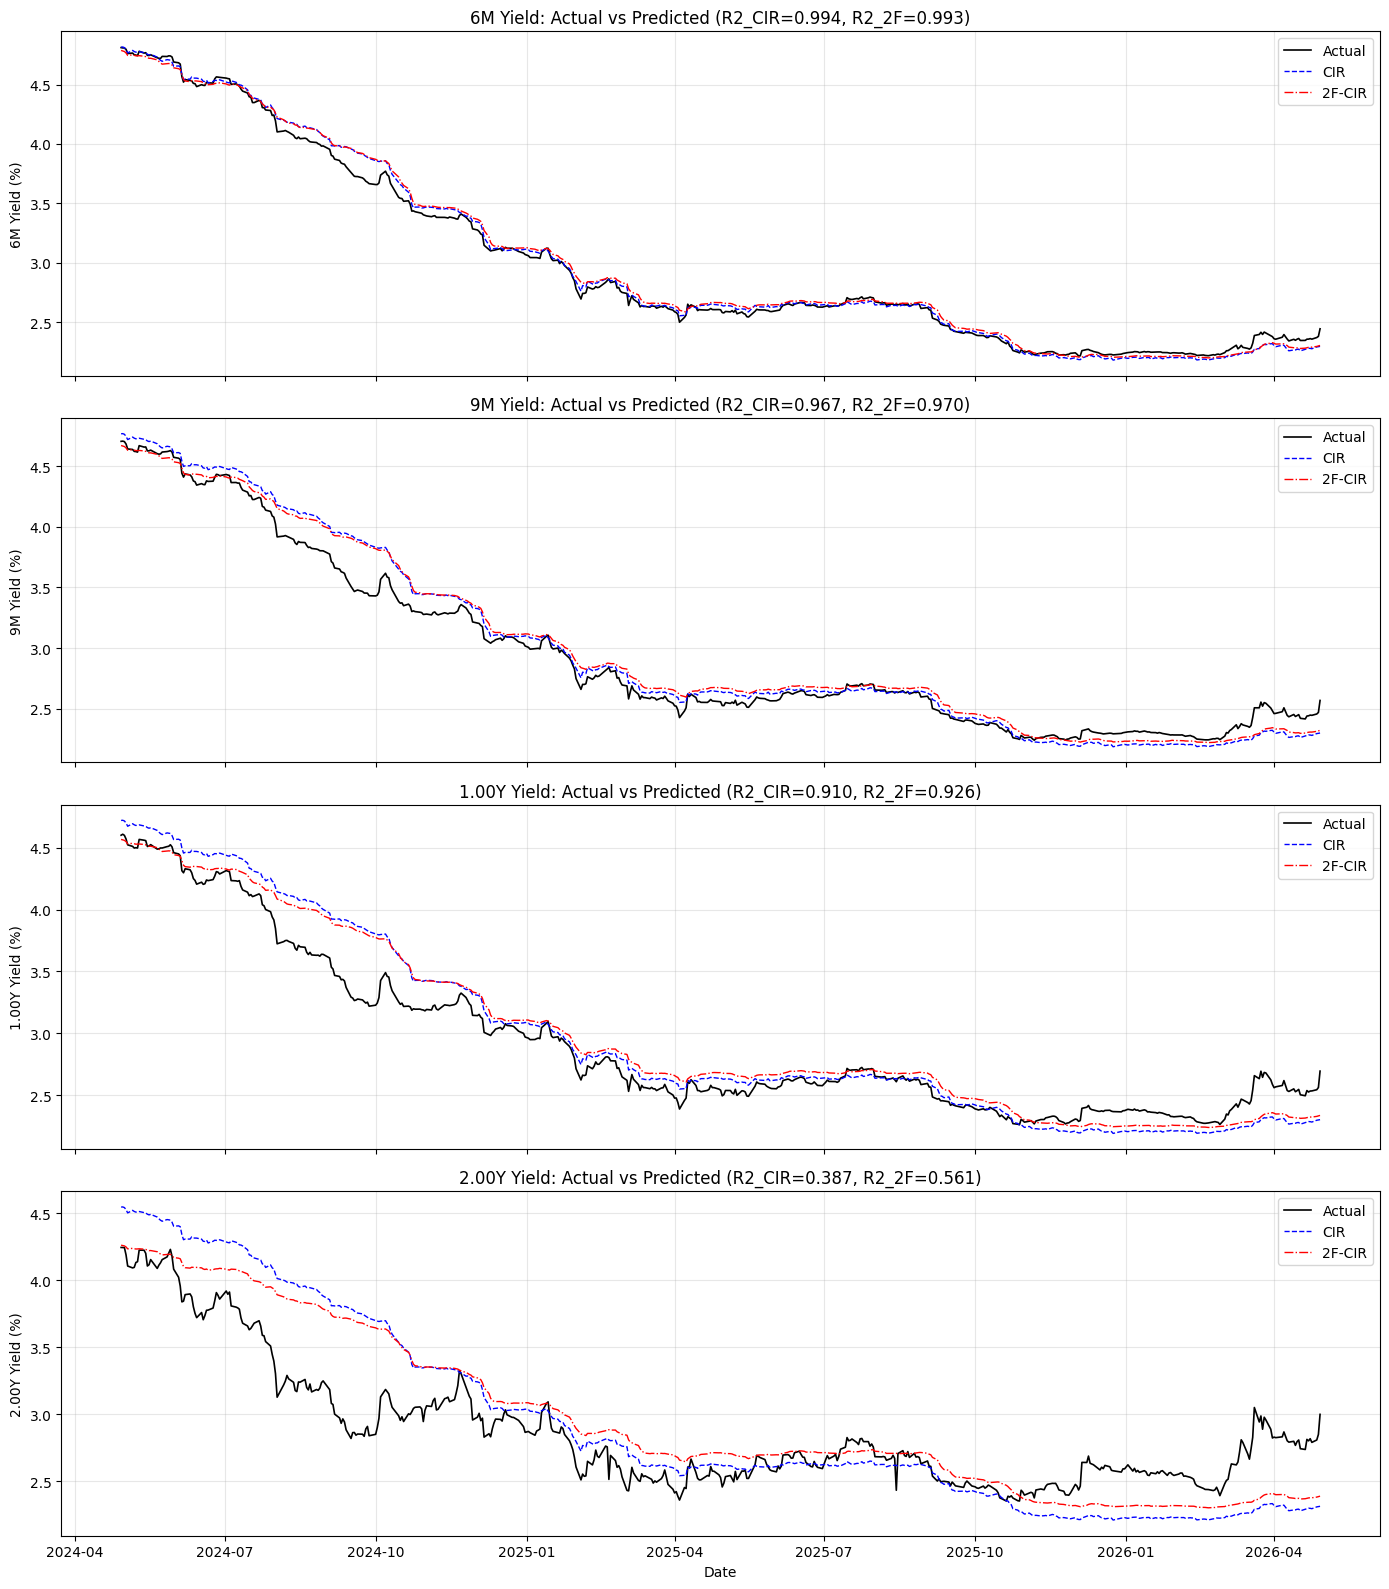

In [ ]:
dates_test = test_df['Date'].values

# Plot 1: Time Series Comparison
fig, axes = plt.subplots(len(pred_cols), 1, figsize=(14, 4 * len(pred_cols)), sharex=True)
if len(pred_cols) == 1:
    axes = [axes]

for j, (col, tau) in enumerate(zip(pred_cols, pred_taus)):
    ax = axes[j]
    mat_label = f"{tau:.2f}Y" if tau >= 1 else f"{int(tau*12)}M"
    r2_c = r2_score(actual_test[:, j], cir_preds[:, j])
    r2_2f = r2_score(actual_test[:, j], tf_preds[:, j])

    ax.plot(dates_test, actual_test[:, j] * 100, 'k-', linewidth=1.2, label='Actual')
    ax.plot(dates_test, cir_preds[:, j] * 100, 'b--', linewidth=1, label='CIR')
    ax.plot(dates_test, tf_preds[:, j] * 100, 'r-.', linewidth=1, label='2F-CIR')
    ax.set_ylabel(f'{mat_label} Yield (%)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'{mat_label} Yield: Actual vs Predicted (R2_CIR={r2_c:.3f}, R2_2F={r2_2f:.3f})')

plt.xlabel('Date')
plt.tight_layout()
plt.show()


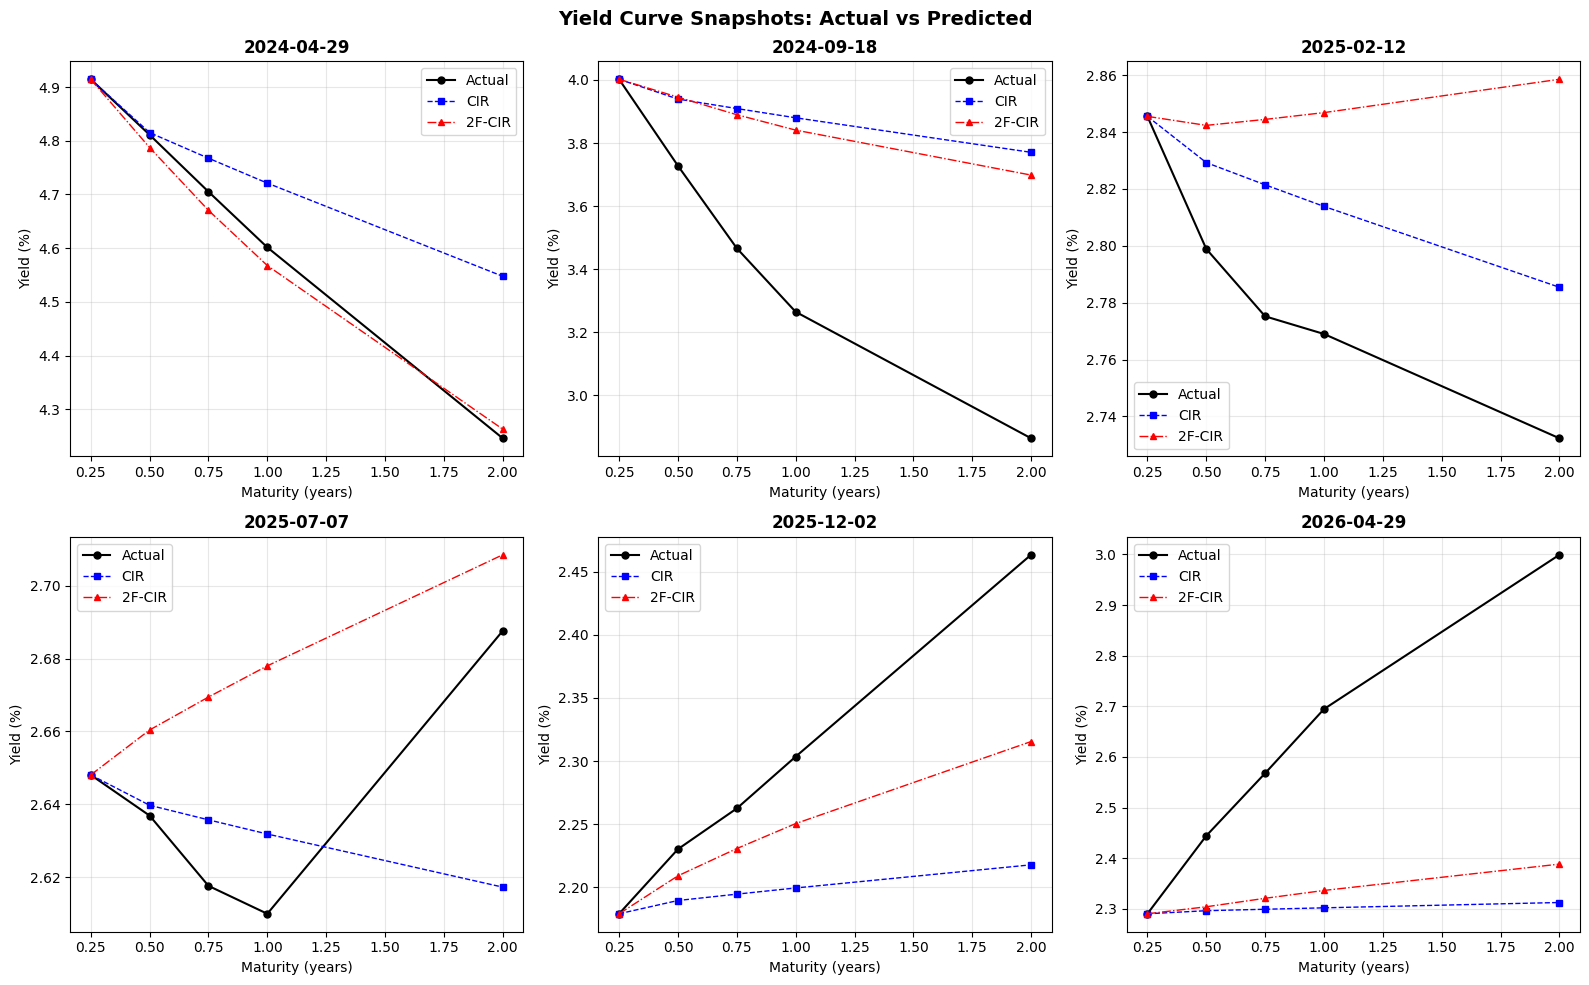

In [ ]:
# Plot 2: Yield Curve Snapshots (at six different dates)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

snapshot_indices = np.linspace(0, N_test - 1, 6, dtype=int)
all_taus = np.array([0.25] + list(pred_taus))

for idx_plot, day_idx in enumerate(snapshot_indices):
    ax = axes[idx_plot]
    date_str = pd.Timestamp(dates_test[day_idx]).strftime('%Y-%m-%d')
    r_day = r_test[day_idx]

    actual_curve = np.concatenate([[r_day], actual_test[day_idx]])
    cir_curve = np.concatenate([[r_day], cir_preds[day_idx]])
    tf_curve = np.concatenate([[r_day], tf_preds[day_idx]])

    ax.plot(all_taus, actual_curve * 100, 'ko-', markersize=5, linewidth=1.5, label='Actual')
    ax.plot(all_taus, cir_curve * 100, 'bs--', markersize=4, linewidth=1, label='CIR')
    ax.plot(all_taus, tf_curve * 100, 'r^-.', markersize=4, linewidth=1, label='2F-CIR')
    ax.set_title(date_str, fontweight='bold')
    ax.set_xlabel('Maturity (years)')
    ax.set_ylabel('Yield (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Yield Curve Snapshots: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


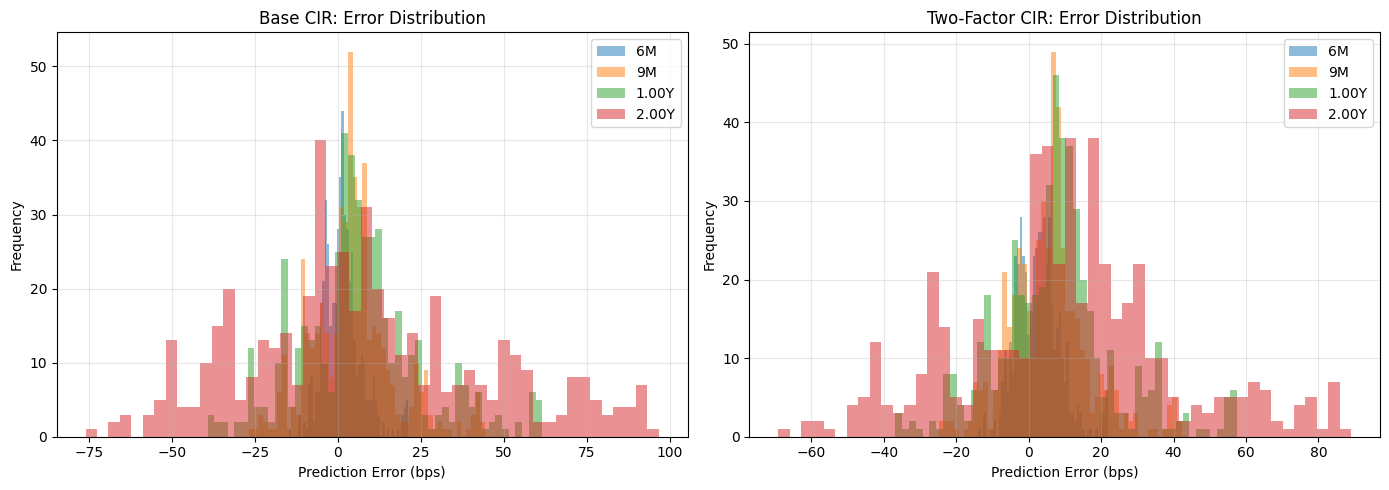

In [ ]:
# Plot 3: Error Distribution Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name in zip(axes, [cir_preds, tf_preds], ['Base CIR', 'Two-Factor CIR']):
    errors = (preds - actual_test) * 10000  # in basis points
    for j, col in enumerate(pred_cols):
        tau = pred_taus[j]
        mat_label = f"{tau:.2f}Y" if tau >= 1 else f"{int(tau*12)}M"
        ax.hist(errors[:, j], bins=50, alpha=0.5, label=mat_label)
    ax.set_xlabel('Prediction Error (bps)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{name}: Error Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Model Analysis & Critical Reflections

1. **Single-Factor vs Two-Factor**:
   - A single-factor model like Base CIR assumes all maturities are driven by a single source of risk ($r_t$). This is heavily constrained, as the shape of the yield curve is fixed once $r_t$ is observed.
   - By adding a second factor ($y_t$), we allow the level (average rate) and slope (spread) to evolve independently, enabling the model to capture time-varying curve slopes dynamically.

2. **State Filtering with Kalman Filter**:
   - In a pure prediction setup, we only observe the 3M rate. A static model would struggle because the mapping from 3M to other rates would have to be static. Using a Kalman Filter allows us to use the historical path of the 3M rate to recursively update our level and slope factor estimates, enabling dynamic adaptation.

3. **Longer Maturities (5Y-30Y)**:
   - Short-rate models like CIR will fail on long-end maturities (e.g. 5Y to 30Y) because they are driven by long-term expectations, inflation, and risk premiums rather than short-rate dynamics. A Nelson-Siegel-Svensson framework or a multi-factor affine model with explicit risk premium factors would be required.


## 8. Model Analysis & Critical Reflections

### Base CIR — Limitations

1. **Single factor is too restrictive.**
    - The base CIR model assumes the entire yield curve is driven by one number i.e. the short rate $r_t$. This means once you observe the 3M rate, the shape of the full curve is completely determined.
    - In reality, the yield curve shifts, flattens, steepens and inverts due to multiple independent forces. Hence, a single factor cannot capture this. It can only produce one fixed curve shape per level of $r_t$.

2. **Mean reversion is constant.**
    - The model assumes $\kappa$ (speed of mean reversion) and $\theta$ (long-run mean) are fixed forever.
    - In practice, the Fed's target rate changes, inflation regimes shift and the market's long-run rate expectations evolve.
    - Calibrating on 2022–2024 data partially addresses this, but the parameters will still drift over time.

3. **Volatility scales with $\sqrt{r_t}$, nothing else.**
    - The $\sigma\sqrt{r_t}$ term means volatility is fully determined by the current rate level. This rules out volatility clustering, sudden spikes or regime changes in volatility — all of which are common in real bond markets.

4. **Feller condition may not hold in practice.**
    - The condition $2\kappa\theta \geq \sigma^2$ ensures rates stay positive. But calibrated parameters don't always satisfy this, and even when they do, near-zero rates cause numerical instability in the $\sqrt{r_t}$ diffusion term.

---

### Two-Factor CIR — Limitations

1. **More expressive but harder to interpret.**
    - The two factors are mathematical constructs (level and slope), not directly observable quantities.
    - This makes it harder to validate the model intuitively or communicate its outputs to non-technical stakeholders in a trading or risk context.

2. **Kalman Filter assumes Gaussian noise.**
    - The Kalman Filter is optimal only when observation and transition noise are Gaussian and the system is linear.
    - CIR dynamics are non-linear and the noise is not truly Gaussian, so the standard Kalman Filter is an approximation here, not an exact solution.
    - An Extended or Unscented Kalman Filter would be more theoretically correct.

3. **Calibration is unstable with more parameters.**
    - Six parameters instead of three, means the optimization landscape has more local minima and more ways to overfit.
    - Two sets of parameters can produce very similar training fits but diverge significantly on test data.

---

### Shared Limitations — Both Models

1. **Long-end maturities (5Y–30Y) are structurally mismatched.**
    - Short-rate models are designed to explain the short end of the curve.
    - Long-maturity yields are driven by inflation expectations, term premiums and long-run fiscal outlooks.
    - Both models will systematically struggle at 5Y, 10Y, 20Y, and 30Y regardless of how well they are calibrated.
    - A Nelson-Siegel-Svensson framework or a multi-factor affine term structure model with explicit risk premium factors would be more appropriate for the long end.

2. **No market price of risk.**
    - Under the real-world measure, investors demand a premium for holding longer-duration bonds.
    - The CIR model as implemented here does not account for this. It prices bonds as if investors are risk-neutral.
    - In a real trading or risk-management context, this would lead to systematic mispricing of longer-dated instruments.

3. **Static calibration window.**
    - Both models are calibrated once on a fixed training window and then frozen.
    - In live trading, yield curve shifts dynamically — a model calibrated on 2022–2024 data will gradually go stale as the rate environment evolves.
    - In practice, models are recalibrated periodically or run in a rolling-window setup.

---

### Implications for Trading and Risk Management

- These models are reasonable for **relative value analysis** on the short end (3M–2Y) in a stable rate environment, but should not be used for outright pricing of long-dated instruments.
- For **VaR or duration hedging**, the single-factor assumption is dangerous — it implies perfect correlation across all maturities, which underestimates tail risk when the curve twists or inverts unexpectedly.
- For **desk use**, the two-factor model is more suitable given its ability to capture slope dynamics, but would need to be extended with a risk premium component and recalibrated on a rolling basis to be production-grade.